In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [104]:
#Load dataset
file_path = "lung_cancer_labeled_dataset_numerical.csv"
df = pd.read_csv(file_path)
df

,Patient_ID,Age,Gender,Tumor_Size_mm,Stage,Metastasis,Gene_Mutation,Smoking_History,Family_History,Radiation_Exposure,Imaging_Result,Blood_Marker_Level,Survival_Months,Label
0,PID0003,47,0,10.2,0,0,2,2,0,0,1,19.48,49,1
1,PID0006,48,0,23.7,0,0,0,1,1,0,1,13.28,51,1
2,PID0009,54,0,30.1,1,0,3,2,0,1,0,17.48,39,1
3,PID0011,59,1,24.8,0,1,4,1,1,1,0,13.37,71,1
4,PID0019,81,1,96.1,0,1,3,2,1,1,0,2.84,114,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PID0148,57,1,30.5,0,0,2,1,0,0,1,4.26,15,0
996,PID0152,84,0,64.2,2,0,5,0,1,0,1,9.37,78,1
997,PID0156,20,1,5.5,2,1,5,0,1,2,0,8.47,99,0
998,PID0163,38,0,56.7,3,1,0,0,0,0,1,18.48,109,1


In [106]:
# Drop Patient_ID as it is not useful for modelling
df = df.drop(columns=["Patient_ID"])

In [108]:
# Split features and target
X = df.drop(columns=["Label"])
y = df["Label"]

In [110]:
# Splitting into training and testing sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [112]:
# Standardizing the features
scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
#Training the logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [116]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [118]:
print("Accuracy: ", accuracy)
print("Classification Report:\n", classification_rep)

Accuracy:  0.505
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.42      0.46        99
           1       0.51      0.58      0.54       101

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.51      0.50       200



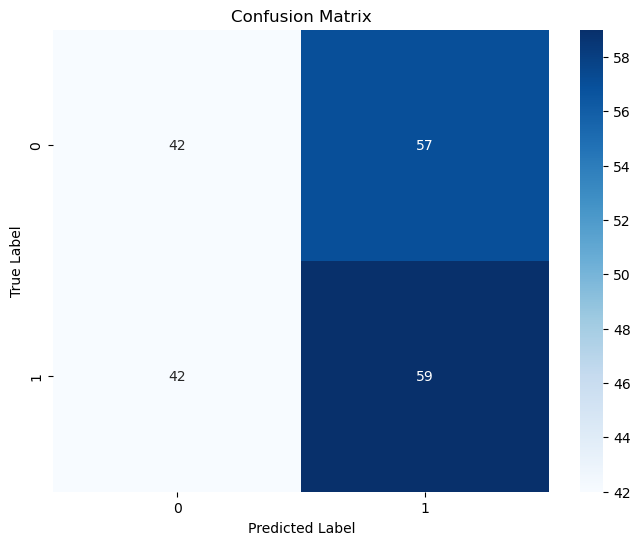

In [130]:
# Confusion matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()